In [8]:
import sys
import os
import glob 
import time
os.environ['CUDA_VISIBLE_DEVICES']="0"
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from collections import defaultdict
import numpy as np
import dask.dataframe as dd
from matplotlib import pyplot as plt
from tqdm import tqdm
from joblib import Parallel, delayed
from scipy.stats import boxcox
from scipy import stats
import polars as pl
import pandas as pd
from itertools import groupby

# AGE

In [2]:
def log_log_transform(y, epsilon=1e-10):
    """Apply log(log(y)) transformation for doubly exponential data"""
    # Ensure y > 0 for double log
    y_positive = y - y.min() + 1  # Shift to ensure y > 0
    return np.log(np.log(y_positive + epsilon))

In [3]:
embeddings_path = '/mnt/local/data/ksozykin/src/ESdB/raw_embd/embeddings_age_coles_ntp_TILL.parquet'
embeddings_path_prepocessed = '/mnt/local/data/ksozykin/src/ESdB/embeddings_age_coles.parquet'
parquet_df = pd.read_parquet(embeddings_path).dropna()
#embeddings_df = parquet_df[parquet_df['used_in_train'] == 0]
embeddings_df = parquet_df.copy()
embeddings_df['post_anomaly_target'] = embeddings_df['post_small_group'].apply(
    lambda x: 1 if (189 in x) or (197 in x) else 0
)
post_trans_date = embeddings_df['post_trans_date'].values
embeddings_df['post_forecast_target'] = ([ np.sum(v == v[0])  for v in embeddings_df['post_trans_date'].values])
y = embeddings_df['post_forecast_target']
y_transformed = np.log1p(y)
embeddings_df['post_forecast_target'] =  y_transformed
#embeddings_df['post_forecast_target'] = boxcox(embeddings_df['post_forecast_target'].values)[0]
embeddings_df['post_amount'] = np.array(embeddings_df['post_amount_rur'].values)
embeddings_df.drop(['post_amount_rur'], axis=1, inplace=True)
embeddings_df['post_target'] = np.array(embeddings_df['target'].values)
#post_group is ntp target
embeddings_df['post_group'] = np.array(embeddings_df['post_small_group'].values)
embeddings_df.drop(['post_small_group'], axis=1, inplace=True)
embeddings_df.to_parquet(embeddings_path_prepocessed)

In [ ]:
transformations = {
    'original': embeddings_df['post_forecast_target'],
    'log1p': np.log1p(embeddings_df['post_forecast_target']),
    'sqrt': np.sqrt(embeddings_df['post_forecast_target']),
    'cube_root': embeddings_df['post_forecast_target'] ** (1/3),
    'fourth_root': embeddings_df['post_forecast_target'] ** 0.25,
    'log_log': np.log(np.log1p(embeddings_df['post_forecast_target'] + 1e-10)),
}

# Plot each transformation
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for (name, data), ax in zip(transformations.items(), axes.flatten()):
    ax.hist(data, bins=50, alpha=0.7)
    ax.set_title(f'{name} (skew: {stats.skew(data):.2f})')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [ ]:
plt.hist(boxcox(embeddings_df['post_forecast_target']),bins='auto')

In [ ]:
plt.hist([ np.sum(v == v[0])  for v in embeddings_df['post_trans_date'].values])

In [ ]:
plt.hist(AGE_DF['post_forecast_target'])

# X5

In [ ]:
def get_x5_anomaly(df):
    df['post_transaction_datetime'] = pd.to_datetime(df['post_transaction_datetime'])
    # клиенты, у которых есть транзакции с redemption
    clients_red = df.loc[df['post_trn_sum_from_red'] > 0, 'client_id'].unique()
    df_red = df[df['client_id'].isin(clients_red)].copy()
    # время, когда была первая redemption транзакция
    first_red = (
        df[df['post_trn_sum_from_red'] > 0]
        .groupby('client_id')['post_transaction_datetime']
        .min()
        .rename("first_redemption_dt")
    )
    df_red = df_red.merge(first_red, on='client_id', how='left')
    # таргеты аномалии
    df_red['is_first_red_trx'] = (
        df_red['post_transaction_datetime'] == df_red['first_redemption_dt']
    ).astype(int)
    return df_red['is_first_red_trx'].values

def process_row_for_anomaly(row):
    client_df = pd.DataFrame({
        'post_transaction_datetime': pd.to_datetime(row['post_transaction_datetime']),
        'post_trn_sum_from_red': np.array(row['post_trn_sum_from_red'], dtype=float),
        'client_id': [row['client_id']] * len(row['post_transaction_datetime'])
    })
    return 1 if np.sum(get_x5_anomaly(client_df)) > 10 else 0

def parallel_anomaly_joblib(df, n_jobs=-1):
    """
    Parallel processing with joblib (better memory handling)
    """
    # Process each row in parallel
    results = Parallel(n_jobs=n_jobs)(
        delayed(process_row_for_anomaly)(row)
        for _, row in df.iterrows()
    )
    
    return np.array(results)


In [ ]:
embeddings_path = '/mnt/local/data/ksozykin/src/ESdB/raw_embd/embeddings_x5_coles_ntp_TILL_best.parquet'
parquet_df = pd.read_parquet(embeddings_path).dropna().head(30*1000)
embeddings_df = parquet_df.copy()
embeddings_df['post_target'] =  embeddings_df['age_clf'] #pd.cut(embeddings_df['post_age'], bins=4, labels=False)
embeddings_df['post_amount'] = embeddings_df['post_purchase_sum'].copy()
embeddings_df['post_amount_2'] = embeddings_df['post_netto'].copy()
post_level = 'post_level_2'
embeddings_df['post_group'] = np.array(embeddings_df[post_level].values)
embeddings_df.drop([post_level], axis=1, inplace=True)
embeddings_df['post_anomaly_target'] = parallel_anomaly_joblib(
    embeddings_df[['client_id', 'post_transaction_datetime', 'post_trn_sum_from_red']],
    n_jobs=16
)
embeddings_df['post_trans_date'] = embeddings_df['post_transaction_datetime']
embeddings_df['post_forecast_target'] = embeddings_df.apply(
    lambda row: (
        ( pd.to_datetime(row['post_transaction_datetime'])[1] -pd.to_datetime(row['transaction_datetime'])[-1]
        ).total_seconds() / 86400
        if len(row['post_transaction_datetime']) > 0 and len(row['transaction_datetime']) > 0
        else np.nan
    ),
    axis=1
)
# Calculate percentiles
low_percentile = 1  # 1st percentile
high_percentile = 99  # 99th percentile

lower_bound = np.percentile(embeddings_df['post_forecast_target'].dropna(), low_percentile)
upper_bound = np.percentile(embeddings_df['post_forecast_target'].dropna(), high_percentile)

# Filter outliers
filtered_df = embeddings_df[
    (embeddings_df['post_forecast_target'] >= lower_bound) & 
    (embeddings_df['post_forecast_target'] <= upper_bound)
]
post_forecast_target = np.log1p(filtered_df['post_forecast_target'])

print(f"Removed values < {lower_bound:.2f} and > {upper_bound:.2f}")
print(f"Original: {len(embeddings_df)} rows, Filtered: {len(filtered_df)} rows")
embeddings_path_prepocessed = f'/mnt/local/data/ksozykin/src/ESdB/embeddings_x5_coles_{post_level}.parquet'
filtered_df.to_parquet(embeddings_path_prepocessed)

# taobao

In [ ]:
def get_taobao_anomaly(path):
    # предсказание поведения пользователя: кладет товар в корзину, но не покупает его
    embed_taobao = pl.scan_parquet(path)
    coll_embed_taobao = embed_taobao.collect()
    df_seq = coll_embed_taobao.to_pandas().copy().dropna()
    # какие колонки хотим развернуть в обычный вид
    cols_to_explode = ["time", "behavior_type", "item_id"]

    # разворачиваем построчно
    pd_df_concat = (
        df_seq[["user_id"] + cols_to_explode]
        .explode(cols_to_explode)
        .reset_index(drop=True)
    )

    # приводим время и сортируем
    pd_df_concat["time"] = pd.to_datetime(pd_df_concat["time"])
    pd_df_concat = pd_df_concat.sort_values(["user_id", "time"]).reset_index(drop=True)

    ITEM_COL = "item_id"

    # 4 — добавление в корзину
    df_add_item = (
        pd_df_concat[pd_df_concat["behavior_type"] == 4]
        [["user_id", ITEM_COL, "time"]]
        .rename(columns={"time": "timestamp_add"})
    )

    # 3 — покупка
    df_buy_item = (
        pd_df_concat[pd_df_concat["behavior_type"] == 3]
        [["user_id", ITEM_COL, "time"]]
        .rename(columns={"time": "timestamp_buy"})
    )

    # для каждой пары (user, item) смотрим, был ли add без buy
    merged_item = df_add_item.merge(
        df_buy_item,
        on=["user_id", ITEM_COL],
        how="left"
    )

    # аномалия: добавил в корзину, но не купил
    anom_item = merged_item[merged_item["timestamp_buy"].isna()]

    print("Аномальных (client, item):", len(anom_item))

    # пары (user, item), где есть такая аномалия
    anom_pairs = anom_item[["user_id", ITEM_COL]].drop_duplicates()
    anom_pairs["anomaly_item_cart_no_buy"] = True

    # добавляем флаг
    pd_df_concat = pd_df_concat.merge(
        anom_pairs,
        on=["user_id", ITEM_COL],
        how="left"
    )

    pd_df_concat["anomaly_item_cart_no_buy"] = (
        pd_df_concat["anomaly_item_cart_no_buy"]
        .fillna(False)
    )

    # момент первой аномальной корзины по пользователю
    first_cart_time_item = (
        anom_item
        .groupby("user_id")["timestamp_add"]
        .min()
        .rename("first_anomaly_time_item")
    )

    pd_df_concat = pd_df_concat.merge(first_cart_time_item, on="user_id", how="left")

    # фаза относительно первой аномалии
    pd_df_concat["trget_anomaly_cart_no_buy"] = np.where(
        pd_df_concat["first_anomaly_time_item"].notna() &
        (pd_df_concat["time"] >= pd_df_concat["first_anomaly_time_item"]),
        "post",
        "pre"
    )

    pd_df_concat = pd_df_concat.sort_values(["user_id", "time"]).reset_index(drop=True)

    # возвращаем в изначальный вид
    phase_seq = (
        pd_df_concat
        .groupby("user_id")["trget_anomaly_cart_no_buy"]
        .apply(list)                      
        .reset_index()
    )

    phase_seq = phase_seq.rename(
        columns={"trget_anomaly_cart_no_buy": "trget_anomaly_cart_no_buy_seq"}
    )
    df_seq = df_seq.merge(phase_seq, on="user_id", how="left")
    post_anomaly_target = [ int('post' in v) for v in df_seq['trget_anomaly_cart_no_buy_seq'].values]
    return post_anomaly_target

In [ ]:
def get_taobao_forecast(path):
    embed_taobao = pl.scan_parquet(path)
    coll_embed_taobao = embed_taobao.collect()
    df_fore = coll_embed_taobao.to_pandas().copy().dropna()
    cols_to_explode = ['time', "item_id", "behavior_type"]
    df_fore_exp = (
        df_fore[["user_id"] + cols_to_explode]
        .explode(cols_to_explode)
        .reset_index(drop=True)
    )
    df_fore_exp["time"] = pd.to_datetime(df_fore_exp["time"])
    df_fore_exp = df_fore_exp.sort_values(["user_id", "time"]).reset_index(drop=True)
    is_transaction = df_fore_exp["behavior_type"] == 3
    df_fore_exp["last_trx_time"] = np.where(is_transaction, df_fore_exp["time"], pd.NaT)
    df_fore_exp["last_trx_time"] = (
        df_fore_exp
        .groupby("user_id")["last_trx_time"]
        .ffill()
    )
    df_fore_exp["last_trx_time"] = pd.to_datetime(df_fore_exp["last_trx_time"])
    delta = df_fore_exp["time"] - df_fore_exp["last_trx_time"]
    df_fore_exp["time_since_last_tx_days"] = delta.dt.total_seconds() / (3600 * 24)
    target_forecast_df = df_fore_exp[
        df_fore_exp["time_since_last_tx_days"].notna()
        & (df_fore_exp["time_since_last_tx_days"] > 0)
    ]
    target_seq = (
        df_fore_exp
        .groupby("user_id")["time_since_last_tx_days"]
        .apply(list)                      
        .reset_index()
    )

    df_fore_final = (
        df_fore
        .merge(target_seq, on="user_id", how="left")
    )
    return np.stack(df_fore_final["time_since_last_tx_days"])

In [ ]:
users = pd.read_csv('/mnt/local/data/ksozykin/src/ESdB/raw_embd/tianchi_mobile_recommend_train_user.csv')
item_to_category = {
    str(k): str(v) for k, v in zip(users['item_id'], users['item_category'])
}

In [ ]:
def remove_consecutive_duplicates(lst):
    """Remove consecutive duplicates from a list"""
    if not lst:
        return []
    result = [lst[0]]
    for i in range(1, len(lst)):
        if lst[i] != lst[i-1]:
            result.append(lst[i])
    return result

In [ ]:
def map_without_consecutive_duplicates(item_list):
    categories = []
    last_category = None
    for item_id in item_list:
        category = item_to_category_dict.get(item_id)
        if category is not None and category != last_category:
            categories.append(category)
            last_category = category
    return categories

In [ ]:
embeddings_path = '/mnt/local/data/ksozykin/src/ESdB/raw_embd/embeddings_taobao_coles_ntp_TILL_best.parquet'

parquet_df = pd.read_parquet(embeddings_path).dropna()#.head(1000)
embeddings_df = parquet_df.copy()
embeddings_df['post_target'] = list(embeddings_df['target'].values)
#embeddings_df['post_trans_date'] = np.array(embeddings_df['post_time'].values)
embeddings_df['post_amount'] = embeddings_df['post_behavior_type'] #[np.zeros_like(t).astype('int') for t in embeddings_df['post_time'].values]
embeddings_df['post_anomaly_target']  = get_taobao_anomaly(embeddings_path)

embeddings_df['post_trans_date'] = np.array(embeddings_df['post_time'].values)
embeddings_df['client_id'] = np.array(embeddings_df['user_id'].values)

post_forecast_target = get_taobao_forecast(embeddings_path)
embeddings_df['post_forecast_target'] = [np.nanmedian(v) for v in post_forecast_target]

# Map to categories without duplicates
embeddings_df['post_group'] = embeddings_df['post_item_id'].apply(map_without_consecutive_duplicates)

# Use raw item IDs instead of categories
#embeddings_df['post_group'] = embeddings_df['post_item_id'].apply(lambda lst: [key for key, _ in groupby(lst)])

embeddings_df = embeddings_df[embeddings_df['post_group'].apply(len) > 0].copy()
embeddings_df = embeddings_df.dropna()
embeddings_path_prepocessed = "/mnt/local/data/ksozykin/src/ESdB/embeddings_taobao_coles.parquet"
embeddings_df.to_parquet(embeddings_path_prepocessed)

In [ ]:
embeddings_df['post_group']

# Zvuk

In [15]:
def get_zvuk_post_target(embeddings_path, max_users=150000):
    df_pd = pd.read_parquet(embeddings_path).dropna().head(max_users)
    # Load artists data
    artists = pd.read_parquet('./raw_embd/zvuk-track_artist_embedding.parquet')
    track_to_cluster = dict(zip(artists['track_id'].astype(str), artists['cluster_id'].astype(str)))
    # EXPLODE the track_id lists first
    df_exploded = df_pd.explode('track_id').reset_index(drop=True)
    # Now map track_id to cluster_id
    df_exploded['cluster_id'] = df_exploded['track_id'].astype(str).map(track_to_cluster)
    # Filter out rows with no cluster_id
    df_exploded = df_exploded[df_exploded['cluster_id'].notna()].copy()
    # Count unique users per cluster
    unique_users = (
        df_exploded.groupby("cluster_id")["user_id"]
        .nunique()
        .rename("n_users")
    )
    # Create quartiles (handle duplicates)
    qlabels = [0, 1, 2, 3]
    cluster_meta = pd.DataFrame({
        "n_users": unique_users,
        "target_user_quartile": pd.qcut(unique_users, q=4, labels=qlabels, duplicates='drop')
    }).reset_index()
    # Merge with original data
    merged = df_exploded.merge(cluster_meta, on="cluster_id", how="left")
    # Group back into lists per user
    cols_to_list = ["datetime", "track_id", "cluster_id", "n_users", "target_user_quartile"]
    df_list = merged.groupby("user_id")[cols_to_list].agg(list).reset_index()
    return df_list["target_user_quartile"].values


def get_zvuk_post_amount(embeddings_path, max_users=150000):
    df = pd.read_parquet(embeddings_path).dropna().head(max_users)
    # разворачиваем списки в строки
    df = df.explode(["datetime", "play_duration", "track_id"]).reset_index(drop=True)
    df["date"] = pd.to_datetime(df["datetime"]).dt.date
    # получаем активность посуточную
    daily = (
        df.groupby(["user_id", "date"])
        .agg(
            total_play_duration=("play_duration", "sum")
        )
        .reset_index()
    )
    daily = daily.sort_values(["user_id", "date"])
    # создаём таргет: play_duration следующего дня
    daily["target_play_duration_next_day"] = (
        daily.groupby("user_id")["total_play_duration"].shift(-1)
    )
    # убираем последние дни (где таргета нет)
    df_targets = daily.dropna(subset=["target_play_duration_next_day"]).copy()
    user_targets = df_targets[["user_id", "target_play_duration_next_day"]].drop_duplicates()
    merged = df.merge(user_targets, on="user_id", how="left")
    # снова собираем в списки
    cols_to_list = ["datetime", "play_duration", "track_id", "target_play_duration_next_day"]
    df_list = (
        merged
        .groupby("user_id")[cols_to_list]
        .agg(list)
        .reset_index()
    )
    return df_list['target_play_duration_next_day'].values


def get_zvuk_forecast(embeddings_path, max_users=150000):
    """
    Predict user activity for next day (how many tracks they'll listen to)
    Returns: list of lists with target_activity_next_day for each user
    """
    df = pd.read_parquet(embeddings_path).dropna().head(max_users)
    # Explode lists
    df_exploded = df.explode(["datetime", "track_id"]).reset_index(drop=True)
    df_exploded["date"] = pd.to_datetime(df_exploded["datetime"]).dt.date
    # Calculate daily activity (count tracks per day)
    daily = (
        df_exploded.groupby(["user_id", "date"])
        .agg(activity=("track_id", "count"))
        .reset_index()
    )
    daily = daily.sort_values(["user_id", "date"])
    # Create target: next day's activity
    daily["target_activity_next_day"] = daily.groupby("user_id")["activity"].shift(-1)
    # Remove last day for each user (no target)
    df_targets = daily.dropna(subset=["target_activity_next_day"]).copy()
    # Get user targets
    user_targets = df_targets[["user_id", "target_activity_next_day"]].drop_duplicates()
    # Merge with original exploded data
    merged = df_exploded.merge(user_targets, on="user_id", how="left")
    # Group back into lists
    cols_to_list = ["datetime", "track_id", "target_activity_next_day"]
    df_list = merged.groupby("user_id")[cols_to_list].agg(list).reset_index()
    return df_list["target_activity_next_day"].values


def get_zvuk_anomaly(embeddings_path, max_users=150000):
    """
    Detect anomalous users with high genre diversity
    Returns: list of lists with binary anomaly labels for each user
    """
    df = pd.read_parquet(embeddings_path).dropna().head(max_users)
    # Load artists data and create track->cluster mapping
    artists = pd.read_parquet('./raw_embd/zvuk-track_artist_embedding.parquet')
    track_to_cluster = dict(zip(artists['track_id'].astype(str), artists['cluster_id'].astype(str)))
    # Explode track_id lists
    df_exploded = df.explode(["datetime", "track_id"]).reset_index(drop=True)
    # Map track_id to cluster_id
    df_exploded['cluster_id'] = df_exploded['track_id'].astype(str).map(track_to_cluster)
    # Filter out rows with no cluster_id
    df_exploded = df_exploded[df_exploded['cluster_id'].notna()].copy()
    # Calculate user diversity statistics
    total_events = df_exploded.groupby("user_id")["cluster_id"].count().rename("total_clusters")
    unique_clusters = df_exploded.groupby("user_id")["cluster_id"].nunique().rename("unique_clusters")
    # Create ratio
    cluster_profile = unique_clusters.to_frame().join(total_events)
    cluster_profile["ratio"] = cluster_profile["unique_clusters"] / cluster_profile["total_clusters"]
    # Find 95th percentile threshold
    q95 = cluster_profile["ratio"].quantile(0.95)
    # Mark anomalies
    cluster_profile["target_is_high_diversity"] = (cluster_profile["ratio"] >= q95).astype(int)
    # Merge back with original data
    merged = df_exploded.merge(
        cluster_profile[["target_is_high_diversity"]].reset_index(),
        on="user_id",
        how="left"
    )
    # Group back into lists
    cols_to_list = ["datetime", "track_id", "cluster_id", "target_is_high_diversity"]
    df_list = merged.groupby("user_id")[cols_to_list].agg(list).reset_index()
    return df_list["target_is_high_diversity"].values

In [26]:
from collections import Counter

In [16]:
embeddings_path = '/mnt/local/data/ksozykin/src/ESdB/raw_embd/part-00000-98ef8977-5fa0-4d34-a5d8-95c01dd1ec57-c000.snappy.parquet'
max_users = 30000
parquet_df = pd.read_parquet(embeddings_path).dropna().head(max_users)
embeddings_df = parquet_df.copy()

t1 = get_zvuk_post_target(embeddings_path, max_users=max_users)
t2 = get_zvuk_post_amount(embeddings_path, max_users=max_users)
t3 = get_zvuk_forecast(embeddings_path, max_users=max_users)
t4 = get_zvuk_anomaly(embeddings_path, max_users=max_users)


embeddings_df['post_trans_date'] = np.array(embeddings_df['post_datetime'].values)
embeddings_df['client_id'] = np.array(embeddings_df['user_id'].values)
embeddings_df['post_target'] = np.array([ Counter(v).most_common(1)[0][0] for v in t1]
embeddings_df['post_amount'] = [v for v in t2]
embeddings_df['post_forecast_target'] = [v for v in t3]
embeddings_df['post_forecast_target'] = np.log1p([np.nanmedian(v) for v in embeddings_df['post_forecast_target'].values])
embeddings_df['post_anomaly_target'] = [np.any(v) for v in t4]
embeddings_df['post_group'] = embeddings_df['post_track_id'].apply(lambda lst: [key for key, _ in groupby(lst)])
embeddings_path_prepocessed = "/mnt/local/data/ksozykin/src/ESdB/embeddings_zvuk_coles.parquet"
embeddings_df.to_parquet(embeddings_path_prepocessed)

/tmp/ipykernel_3259853/2474923799.py:17: RuntimeWarning: All-NaN slice encountered
  embeddings_df['post_forecast_target'] = np.log1p([np.nanmedian(v) for v in embeddings_df['post_forecast_target'].values])


In [30]:
#embeddings_df['post_target'] = np.array([ Counter(v).most_common(1)[0][0] for v in t1])
#embeddings_df.to_parquet(embeddings_path_prepocessed)

# Rossman

In [63]:
embeddings_path = '/mnt/local/data/ksozykin/src/ESdB/raw_embd/embeddings_rossman_coles_ntp_TILL_best_lied.parquet'
max_users = None
parquet_df = pd.read_parquet(embeddings_path).dropna().head(max_users)
embeddings_df = parquet_df.copy()
embeddings_df['post_trans_date'] = np.array(embeddings_df['post_Date'].values)
embeddings_df['client_id'] = np.array(embeddings_df['Store'].values)
embeddings_df['post_amount'] = [np.zeros_like(t).astype('int') for t in embeddings_df['post_trans_date'].values]
store_info_df = pd.read_csv('/mnt/local/data/ksozykin/src/ESdB/raw_embd/store.csv')
store_type_map = dict(zip(store_info_df['Store'], store_info_df['StoreType']))
embeddings_df['store_type_letter'] = embeddings_df['client_id'].map(store_type_map)
# Convert to integer codes
embeddings_df['post_target'] = pd.factorize(embeddings_df['store_type_letter'])[0]
embeddings_df['post_forecast_target'] = np.log1p([np.median(v) for v in embeddings_df['post_Sales']])

embeddings_path_prepocessed = "/mnt/local/data/ksozykin/src/ESdB/embeddings_rossman_coles.parquet"
embeddings_df.to_parquet(embeddings_path_prepocessed)

Text(0.5, 1.0, 'np.log1p(np.median(post_Sales))')

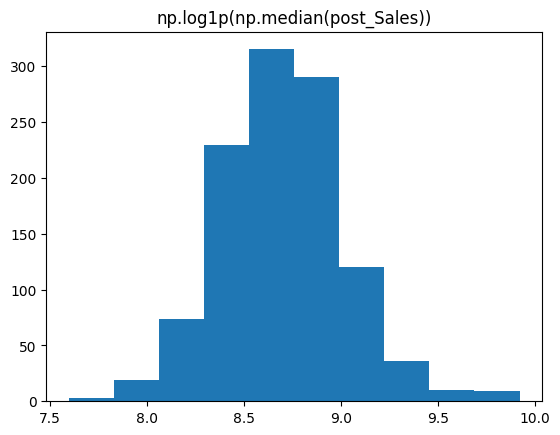

In [69]:
plt.hist(embeddings_df['post_forecast_target'])
plt.title("np.log1p(np.median(post_Sales))")